## 1. Required Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import mne
import yasa
import matplotlib.pyplot as plt
from scipy.signal import welch

## 2. Reading Input Files

In [2]:
base_dir = r"C:\Users\musun\Documents\RA" # base directory
participants = [11, 12, 13, 14, 15] # Participant List

def find_edf_file(base_dir, participant_id):
    folder = os.path.join(base_dir, f"EPCTL{participant_id}")
    matches = glob.glob(os.path.join(folder, "**", "*.edf"), recursive=True)

    if len(matches) == 0:
        raise FileNotFoundError(f"No EDF file found inside {folder}")

    if len(matches) > 1:
        print(f"Multiple EDF files found for Participant {participant_id}:")
        for m in matches:
            print("  ", m)
        print("Using first match.\n")

    return matches[0]

## 3. Smooth Hilbert Envelope Function

In [3]:
def smooth_signal(signal, sfreq, window_sec=0.2):
    
    window_samples = int(window_sec * sfreq)
    window_samples = max(window_samples, 1)

    kernel = np.ones(window_samples) / window_samples
    smoothed = np.convolve(signal, kernel, mode="same")

    return smoothed, window_samples
    

## 4. Manual Spindle Detector

In [4]:
def manual_spindle_detection(edf_path, channel="CZ", k=2.0, smooth_window_sec=0.2):
    raw = mne.io.read_raw_edf(
        edf_path,
        include=[channel],
        preload=True,
        stim_channel=None,
        verbose=False
    )

    sfreq = raw.info["sfreq"]

    # Original single-channel EEG
    eeg = raw.copy()

    # Broad preprocessing filter
    eeg_filt = eeg.copy().filter(l_freq=0.5, h_freq=30.0, verbose=False)

    # Spindle-band filter
    eeg_spindle = eeg_filt.copy().filter(l_freq=11.0, h_freq=16.0, verbose=False)

    # Hilbert envelope
    eeg_env = eeg_spindle.copy().apply_hilbert(envelope=True)

    # Extract as 1D NumPy array
    data = eeg_env.get_data()[0]

     # Smooth the envelope
    smoothed_data, smooth_window_samples = smooth_signal(
        signal=data,
        sfreq=sfreq,
        window_sec=smooth_window_sec
    )

    # Threshold
    mean_val = np.mean(smoothed_data)
    std_val = np.std(smoothed_data)
    threshold = mean_val + k * std_val

    # Above-threshold mask
    above_thresh = smoothed_data > threshold

    # Find transitions
    changes = np.diff(above_thresh.astype(int))
    starts = np.where(changes == 1)[0] + 1
    ends = np.where(changes == -1)[0] + 1

    # Handle edge cases
    if above_thresh[0]:
        starts = np.insert(starts, 0, 0)
    if above_thresh[-1]:
        ends = np.append(ends, len(above_thresh) - 1)

    # Align starts and ends
    n_events = min(len(starts), len(ends))
    starts = starts[:n_events]
    ends = ends[:n_events]

    # Duration filtering
    durations_sec = (ends - starts) / sfreq
    valid_mask = (durations_sec >= 0.5) & (durations_sec <= 2.0)

    valid_starts = starts[valid_mask]
    valid_ends = ends[valid_mask]
    valid_durations = durations_sec[valid_mask]

    # Summary metrics
    total_spindles = len(valid_starts)
    total_time_min = eeg.n_times / sfreq / 60
    density = total_spindles / total_time_min
    avg_duration = np.mean(valid_durations) if total_spindles > 0 else np.nan

    return {
        "raw": eeg,
        "eeg_filt": eeg_filt,
        "eeg_spindle": eeg_spindle,
        "eeg_env": eeg_env,
        "smoothed_env": smoothed_data,
        "sfreq": sfreq,
        "manual_starts": valid_starts,
        "manual_ends": valid_ends,
        "manual_durations": valid_durations,
        "manual_count": total_spindles,
        "manual_density": density,
        "manual_avg_duration": avg_duration,
        "k": k,
        "smooth_window_sec": smooth_window_sec,
        "smooth_window_samples": smooth_window_samples,
        "threshold": threshold
    }

## 5. YASA Spindle Detector

In [5]:
def yasa_spindle_detection(eeg_filt):
    sp_yasa = yasa.spindles_detect(
        eeg_filt,
        freq_sp=(11, 16),
        freq_broad=(0.5, 30),
        verbose=False
    )

    yasa_df = sp_yasa.summary()
    sfreq = eeg_filt.info["sfreq"]
    total_time_min = eeg_filt.n_times / sfreq / 60

    yasa_count = len(yasa_df)
    yasa_density = yasa_count / total_time_min
    yasa_avg_duration = yasa_df["Duration"].mean() if yasa_count > 0 else np.nan

    return {
        "yasa_obj": sp_yasa,
        "yasa_df": yasa_df,
        "yasa_count": yasa_count,
        "yasa_density": yasa_density,
        "yasa_avg_duration": yasa_avg_duration
    } 

## 6. Percent Difference

In [6]:
def percent_difference(manual_val, yasa_val):
    
    if pd.isna(manual_val) or pd.isna(yasa_val):
        return np.nan
    if manual_val == 0:
        return np.nan
    return ((yasa_val - manual_val) / manual_val) * 100

## 7. Finding Overlap Window

In [12]:
def find_overlap_window(manual_starts, manual_ends, yasa_df, sfreq, window_len=20):
    manual_intervals = [(s / sfreq, e / sfreq) for s, e in zip(manual_starts, manual_ends)]
    yasa_intervals = list(zip(yasa_df["Start"].values, yasa_df["End"].values))

    for m_start, m_end in manual_intervals:
        for y_start, y_end in yasa_intervals:
            ov_start = max(m_start, y_start)
            ov_end = min(m_end, y_end)

            if ov_start < ov_end:
                center = (ov_start + ov_end) / 2
                start_sec = max(0, center - window_len / 2)
                end_sec = start_sec + window_len

                overlap_pair = {
                    "manual": (m_start, m_end),
                    "yasa": (y_start, y_end),
                    "overlap": (ov_start, ov_end)
                }

                return (start_sec, end_sec), overlap_pair

    return None, None

## 8. Hyperparameter Tuning (Participant 11)

In [2]:
'''tuning_pid = 11
tuning_edf_path = find_edf_file(base_dir, tuning_pid)

k_values = [1.5, 2.0, 2.5, 3.0]
window_values = [0.1, 0.2, 0.3]

tuning_results = []

print(f"Hyperparameter tuning for Participant {tuning_pid}...\n")

for k in k_values:
    for w in window_values:
        res = manual_spindle_detection(
            edf_path=tuning_edf_path,
            channel="CZ",
            k=k,
            smooth_window_sec=w
        )

        tuning_results.append({
            "Participant": tuning_pid,
            "k": k,
            "Smoothing Window (sec)": w,
            "Spindle Count": res["manual_count"],
            "Density": res["manual_density"],
            "Avg Duration": res["manual_avg_duration"]
        })

        print(
            f"P{tuning_pid} | k={k}, w={w} "
            f"-> Count={res['manual_count']}, "
            f"Density={res['manual_density']:.3f}, "
            f"AvgDur={res['manual_avg_duration']:.3f}"
        )

tuning_df = pd.DataFrame(tuning_results)

print("\nHyperparameter Tuning Results:\n")
print(tuning_df.to_string(index=False))
'''

'tuning_pid = 11\ntuning_edf_path = find_edf_file(base_dir, tuning_pid)\n\nk_values = [1.5, 2.0, 2.5, 3.0]\nwindow_values = [0.1, 0.2, 0.3]\n\ntuning_results = []\n\nprint(f"Hyperparameter tuning for Participant {tuning_pid}...\n")\n\nfor k in k_values:\n    for w in window_values:\n        res = manual_spindle_detection(\n            edf_path=tuning_edf_path,\n            channel="CZ",\n            k=k,\n            smooth_window_sec=w\n        )\n\n        tuning_results.append({\n            "Participant": tuning_pid,\n            "k": k,\n            "Smoothing Window (sec)": w,\n            "Spindle Count": res["manual_count"],\n            "Density": res["manual_density"],\n            "Avg Duration": res["manual_avg_duration"]\n        })\n\n        print(\n            f"P{tuning_pid} | k={k}, w={w} "\n            f"-> Count={res[\'manual_count\']}, "\n            f"Density={res[\'manual_density\']:.3f}, "\n            f"AvgDur={res[\'manual_avg_duration\']:.3f}"\n        )\n\nt

In [8]:
# Hyperparameter Selection based on Participant 11.
selected_k = 2.0
selected_window = 0.2

In [9]:
all_outputs = {}

for pid in participants:
    print(f"\nProcessing Participant {pid}...")

    edf_path = find_edf_file(base_dir, pid)
    print("EDF path:", edf_path)

    manual_res = manual_spindle_detection(
        edf_path=edf_path,
        channel="CZ",
        k=selected_k,
        smooth_window_sec=selected_window
    )

    yasa_res = yasa_spindle_detection(manual_res["eeg_filt"])

    all_outputs[pid] = {
        "manual": manual_res,
        "yasa": yasa_res
    }


Processing Participant 11...
EDF path: C:\Users\musun\Documents\RA\EPCTL11\EPCTL11\EPCTL11.edf

Processing Participant 12...
EDF path: C:\Users\musun\Documents\RA\EPCTL12\EPCTL12\EPCTL12.edf

Processing Participant 13...
EDF path: C:\Users\musun\Documents\RA\EPCTL13\EPCTL13\EPCTL13.edf

Processing Participant 14...
EDF path: C:\Users\musun\Documents\RA\EPCTL14\EPCTL14\EPCTL14.edf

Processing Participant 15...
EDF path: C:\Users\musun\Documents\RA\EPCTL15\EPCTL15\EPCTL15.edf


## Results

### 1. Manual Spindle Detector vs YASA Detector Comparision Table

In [11]:
def print_comparison_table(pid, manual_res, yasa_res):
    """
    Print one comparison table per participant.
    """
    print(f"\nParticipant {pid} Comparison Table:\n")

    manual_count = manual_res["manual_count"]
    yasa_count = yasa_res["yasa_count"]

    manual_density = manual_res["manual_density"]
    yasa_density = yasa_res["yasa_density"]

    manual_duration = manual_res["manual_avg_duration"]
    yasa_duration = yasa_res["yasa_avg_duration"]

    table = pd.DataFrame({
        "Metric": [
            "Total Spindle Count",
            "Spindle Density (Count/Min)",
            "Avg Duration (sec)"
        ],
        "Manual Algorithm": [
            manual_count,
            manual_density,
            manual_duration
        ],
        "YASA (Automated)": [
            yasa_count,
            yasa_density,
            yasa_duration
        ],
        "% Difference": [
            percent_difference(manual_count, yasa_count),
            percent_difference(manual_density, yasa_density),
            percent_difference(manual_duration, yasa_duration)
        ]
    })

    print(table.to_string(index=False))

for pid in participants:
    manual_res = all_outputs[pid]["manual"]
    yasa_res = all_outputs[pid]["yasa"]
    print_comparison_table(pid, manual_res, yasa_res)



Participant 11 Comparison Table:

                     Metric  Manual Algorithm  YASA (Automated)  % Difference
        Total Spindle Count        576.000000        561.000000     -2.604167
Spindle Density (Count/Min)          1.454729          1.416846     -2.604167
         Avg Duration (sec)          0.727024          0.913406     25.636297

Participant 12 Comparison Table:

                     Metric  Manual Algorithm  YASA (Automated)  % Difference
        Total Spindle Count        314.000000        246.000000    -21.656051
Spindle Density (Count/Min)          0.802248          0.628513    -21.656051
         Avg Duration (sec)          0.663025          0.782508     18.020824

Participant 13 Comparison Table:

                     Metric  Manual Algorithm  YASA (Automated)  % Difference
        Total Spindle Count        559.000000       1090.000000     94.991055
Spindle Density (Count/Min)          1.208605          2.356672     94.991055
         Avg Duration (sec)          

### 2. Overlay Plot


Overlay Plot of Participant 11:


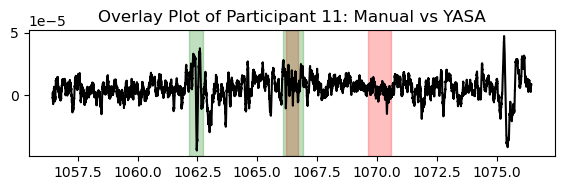


Overlay Plot of Participant 12:


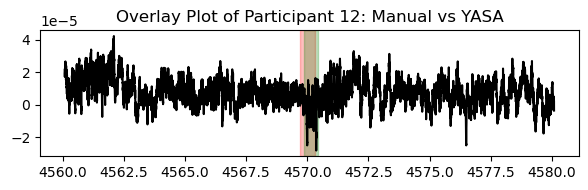


Overlay Plot of Participant 13:


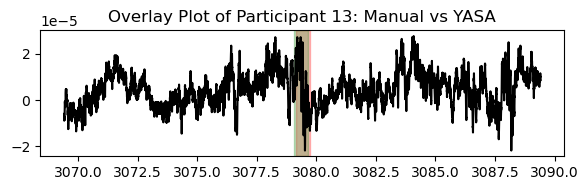


Overlay Plot of Participant 14:


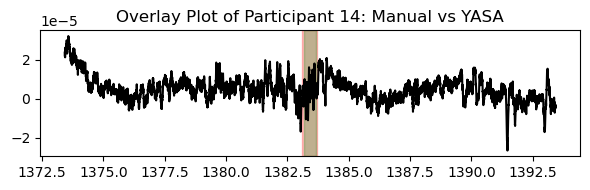


Overlay Plot of Participant 15:


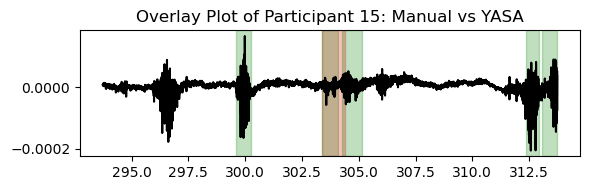

In [13]:
def plot_overlay(eeg, sfreq, manual_starts, manual_ends, yasa_df, start_sec, end_sec, title, figsize=(6, 2)):
    
    start_sample = int(start_sec * sfreq)
    end_sample = int(end_sec * sfreq)

    time = np.arange(start_sample, end_sample) / sfreq
    signal = eeg.get_data()[0][start_sample:end_sample]

    plt.figure(figsize=figsize)
    plt.plot(time, signal, color="black")

    # YASA detections
    for _, row in yasa_df.iterrows():
        s = row["Start"]
        e = row["End"]
        if s < end_sec and e > start_sec:
            plt.axvspan(max(s, start_sec), min(e, end_sec), color="red", alpha=0.25)

    # Manual detections
    for s, e in zip(manual_starts, manual_ends):
        s_sec = s / sfreq
        e_sec = e / sfreq
        if s_sec < end_sec and e_sec > start_sec:
            plt.axvspan(max(s_sec, start_sec), min(e_sec, end_sec), color="green", alpha=0.25)

    plt.title(title)
    plt.tight_layout()
    plt.show()

for pid in participants:
    print(f"\nOverlay Plot of Participant {pid}:")

    manual_res = all_outputs[pid]["manual"]
    yasa_res = all_outputs[pid]["yasa"]

    overlap_window, overlap_pair = find_overlap_window(
        manual_starts=manual_res["manual_starts"],
        manual_ends=manual_res["manual_ends"],
        yasa_df=yasa_res["yasa_df"],
        sfreq=manual_res["sfreq"],
        window_len=20
    )

    if overlap_window is None:
        print(f"No overlap window found for Participant {pid}.")
        continue

    plot_overlay(
        eeg=manual_res["raw"],
        sfreq=manual_res["sfreq"],
        manual_starts=manual_res["manual_starts"],
        manual_ends=manual_res["manual_ends"],
        yasa_df=yasa_res["yasa_df"],
        start_sec=overlap_window[0],
        end_sec=overlap_window[1],
        title=f"Overlay Plot of Participant {pid}: Manual vs YASA",
        figsize=(6, 2)
    )

### 3. PSD Plots


PSD Plot of Participant 11:


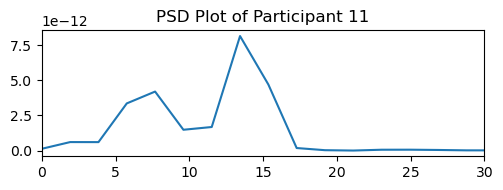


PSD Plot of Participant 12:


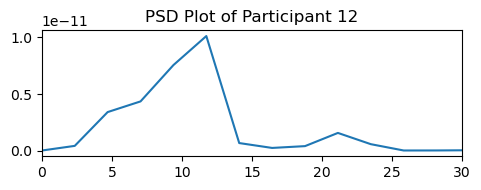


PSD Plot of Participant 13:


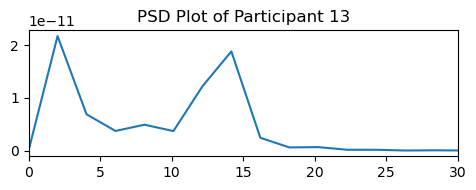


PSD Plot of Participant 14:


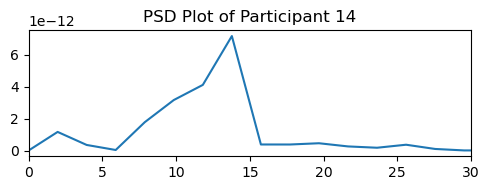


PSD Plot of Participant 15:


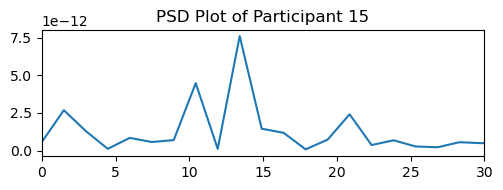

In [14]:
def plot_spindle_psd(eeg, sfreq, start_sec, end_sec, title, figsize=(5, 2)):
    
    start_sample = int(start_sec * sfreq)
    end_sample = int(end_sec * sfreq)

    spindle_signal = eeg.get_data()[0][start_sample:end_sample]

    freqs, psd = welch(
        spindle_signal,
        fs=sfreq,
        nperseg=min(len(spindle_signal), 1024)
    )

    plt.figure(figsize=figsize)
    plt.plot(freqs, psd)
    plt.xlim(0, 30)
    plt.title(title)
    plt.tight_layout()
    plt.show()

for pid in participants:
    print(f"\nPSD Plot of Participant {pid}:")

    manual_res = all_outputs[pid]["manual"]
    yasa_res = all_outputs[pid]["yasa"]

    overlap_window, overlap_pair = find_overlap_window(
        manual_starts=manual_res["manual_starts"],
        manual_ends=manual_res["manual_ends"],
        yasa_df=yasa_res["yasa_df"],
        sfreq=manual_res["sfreq"],
        window_len=20
    )

    if overlap_window is None:
        print(f"No overlap window found for Participant {pid}.")
        continue

    plot_spindle_psd(
        eeg=manual_res["raw"],
        sfreq=manual_res["sfreq"],
        start_sec=overlap_pair["overlap"][0],
        end_sec=overlap_pair["overlap"][1],
        title=f"PSD Plot of Participant {pid}",
        figsize=(5, 2)
    )